
# Mini Project on Coffee Shop Sales Data Using PySpark

# Dataset : Coffee_Shop_Sales.csv



In [23]:
sc

<SparkContext master=local[*] appName=PySparkShell>

# Dataset Insights

The dataset provided contains coffee shop sales transaction details across multiple locations. It records every purchase made in the store network, offering insights into product performance, customer purchasing trends, and store-level revenue. The dataset contains 11 columns: transaction_id, transaction_date, transaction_time, transaction_qty, store_id, store_location, product_id, unit_price, product_category, product_type, and product_detail.
There are no missing values, ensuring high data consistency and reliability for sales analysis.

# 1. Structure and Uniqueness

The dataset comprises multiple thousand rows representing individual sales transactions.
Each sale is uniquely identified by a transaction_id.
The store_id and store_location fields indicate where each sale occurred, while product_id and product_detail specify the exact product sold.
There are multiple unique products and several store locations, showing a diverse product range and a network of operational outlets. This structure supports detailed analyses such as location performance, product category profitability, and sales time trends.

# 2. Store and Location Distribution

The dataset includes multiple store locations, such as Lower Manhattan, Astoria, and Hell’s Kitchen.
Among them, Lower Manhattan records the highest number of transactions, suggesting that it is the busiest outlet or the company’s main branch.
Such data helps identify high-performing locations, evaluate marketing effectiveness, and plan inventory or staffing needs based on regional demand.

# 3. Product Category Distribution

Products are divided into several categories like Coffee, Tea, Drinking Chocolate, and Bakery items.
Coffee-based beverages dominate the dataset, accounting for a significant portion of sales, followed by Tea and Chocolate drinks.
This reflects customer preferences for coffee as the core offering and highlights cross-selling opportunities with complementary products such as bakery items or snacks.

# 4. Sales and Pricing Insights

The unit_price ranges roughly from $1 to $7, depending on the product type and size.
The average unit price lies around $3–$4, showing that the shop primarily serves affordable beverages.
The transaction_qty usually ranges between 1 and 3, implying that most purchases are for individual customers or small groups.
Revenue per transaction, calculated as unit_price × quantity, shows variation across product categories — with premium coffee and chocolate drinks contributing more per sale. This insight helps in understanding profit margins and upselling potential.

# 5. Temporal Trends (Date & Time)

Sales are recorded over a long period, allowing daily and monthly trend analysis.
Typically, transaction volumes peak during morning hours (7 AM – 11 AM), aligning with coffee consumption habits.
Evening hours also see moderate activity, possibly from after-work customers.
Date-based grouping can reveal high-traffic days and seasonal demand patterns — crucial for inventory and workforce planning.

# 6. Product Performance

Certain product types such as Gourmet brewed coffee, Espresso, and Chai tea consistently appear, indicating customer favorites.
Beverages with premium ingredients or brand recognition (like Ethiopia Rg or Dark Chocolate Lg) may drive higher revenues.
Analyzing product mix helps optimize menu offerings, introduce new items, or phase out underperforming ones.

# 7. Revenue Patterns by Location

Revenue analysis reveals that busier city outlets generate the highest overall income, while smaller neighborhoods may see fewer but steadier transactions.
Differences in average revenue per store suggest location-based pricing, customer demographics, or operational efficiency factors.
This information supports targeted marketing campaigns and performance benchmarking.

# 8. Key Relationships

Unit Price vs. Quantity: Lower-priced drinks are sold more frequently, showing a price-sensitive customer base.

Hour vs. Quantity: Morning hours record maximum beverage sales, matching coffee consumption habits.

Store vs. Revenue: Certain stores, such as Lower Manhattan, clearly outperform others in total revenue generation.

Product Category vs. Revenue: Coffee contributes the most revenue, followed by Tea and Chocolate drinks.

# 9. Overall Business Insights

The dataset provides a comprehensive view of operational performance across products, time, and locations.
It is clean, consistent, and well-structured — ideal for data visualization, trend forecasting, and decision-making in retail analytics.
Key findings show:

Coffee remains the top-selling category.

Morning hours drive peak sales.

Lower Manhattan leads in revenue.

Product pricing and category mix directly influence profitability.

In [22]:
import pandas as pd
df=pd.read_csv("Coffee_Shop_Sales.csv")
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,30-06-2023,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,30-06-2023,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,30-06-2023,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,30-06-2023,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


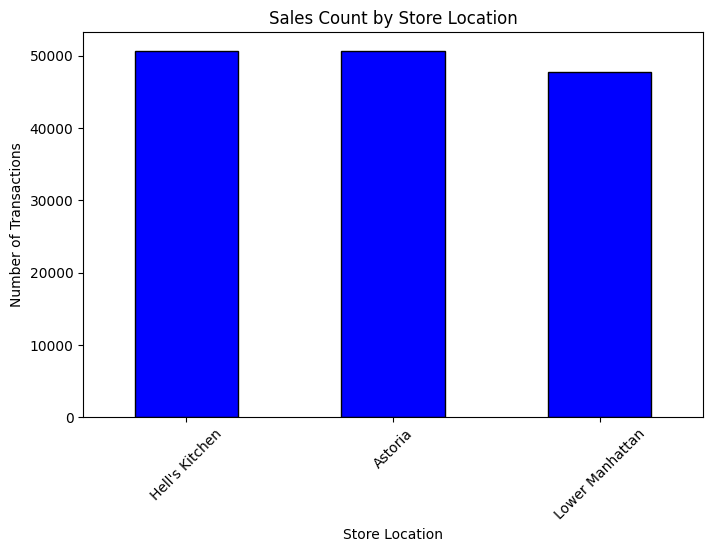

In [5]:
#1. Sales by Store Location
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df['store_location'].value_counts().plot(kind='bar', color='blue', edgecolor='black')
plt.title("Sales Count by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

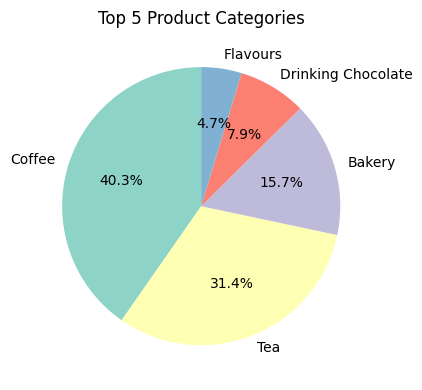

In [20]:
#2. Get top 5 categories 
top_categories = df['product_category'].value_counts().head(5)
plt.figure(figsize=(5,4))
top_categories.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors,
    textprops={'fontsize': 10}
)
plt.title("Top 5 Product Categories", fontsize=12)
plt.ylabel("") 
plt.tight_layout()
plt.show()


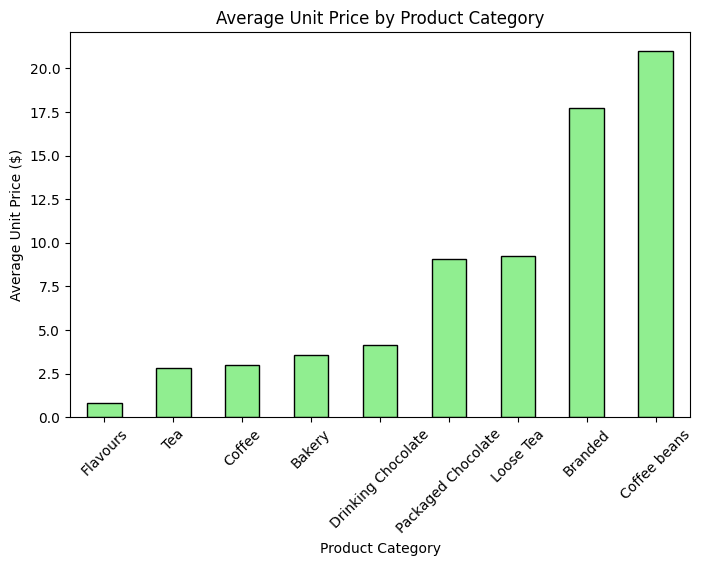

In [7]:
#3. Average Unit Price by Category
plt.figure(figsize=(8,5))
df.groupby('product_category')['unit_price'].mean().sort_values().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Average Unit Price by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Unit Price ($)")
plt.xticks(rotation=45)
plt.show()

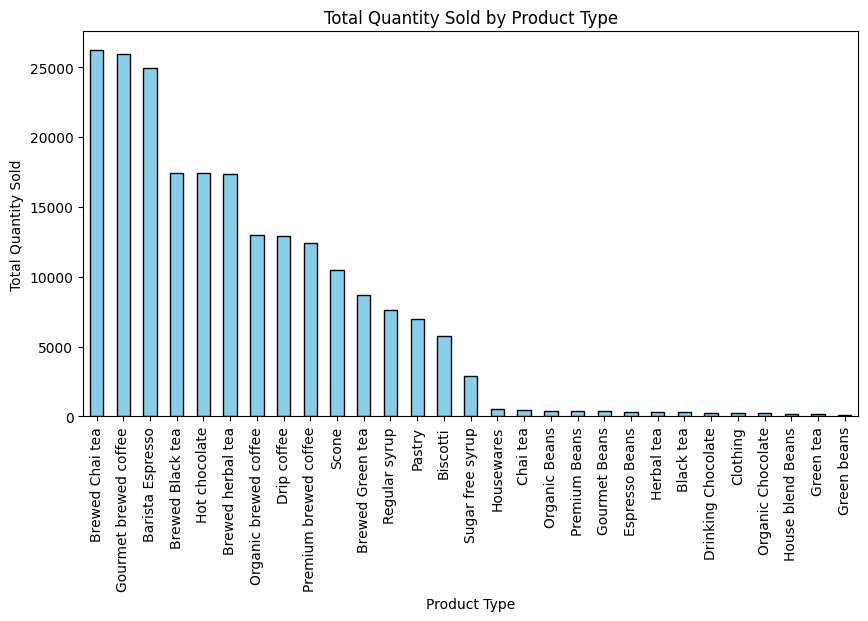

In [8]:
#4. Quantity Sold by Product Type
plt.figure(figsize=(10,5))
df.groupby('product_type')['transaction_qty'].sum().sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Total Quantity Sold by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=90)
plt.show()

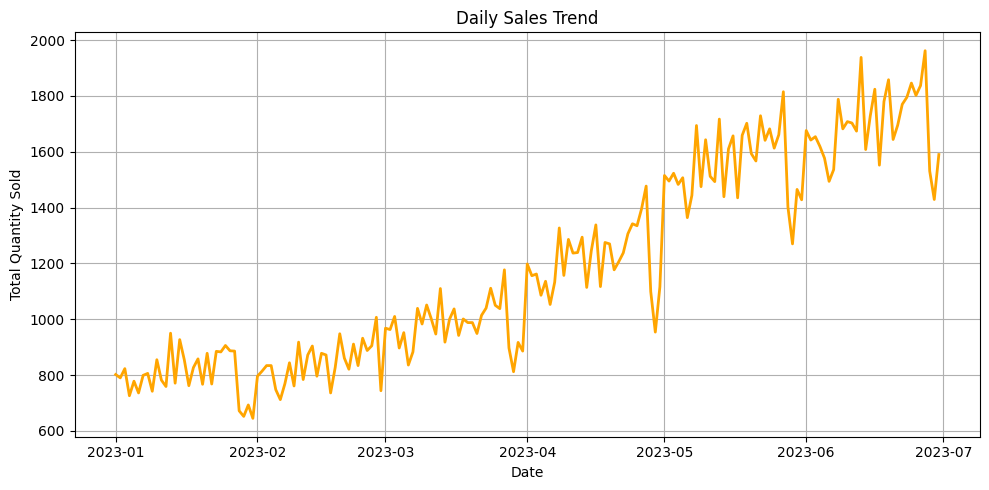

In [12]:
#5.Daily Sales Trend
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True, errors='coerce')
daily_sales = df.groupby('transaction_date')['transaction_qty'].sum()
plt.figure(figsize=(10,5))
plt.plot(daily_sales, color='orange', linewidth=2)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.grid(True)
plt.tight_layout()
plt.show()


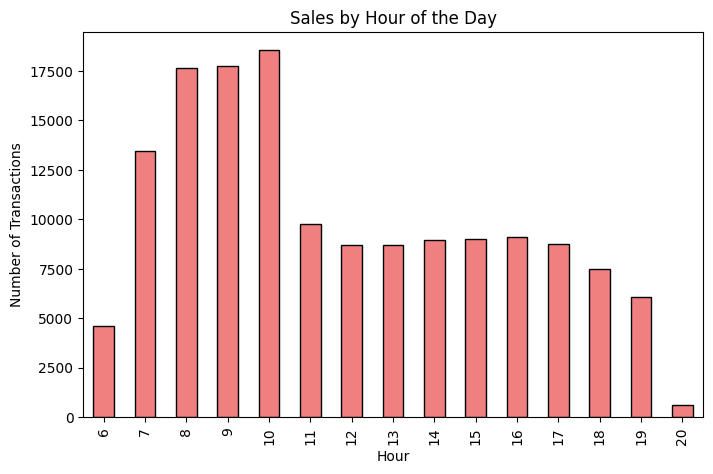

In [10]:
#6. Sales by Hour of the Day
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

plt.figure(figsize=(8,5))
df['hour'].value_counts().sort_index().plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Sales by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()


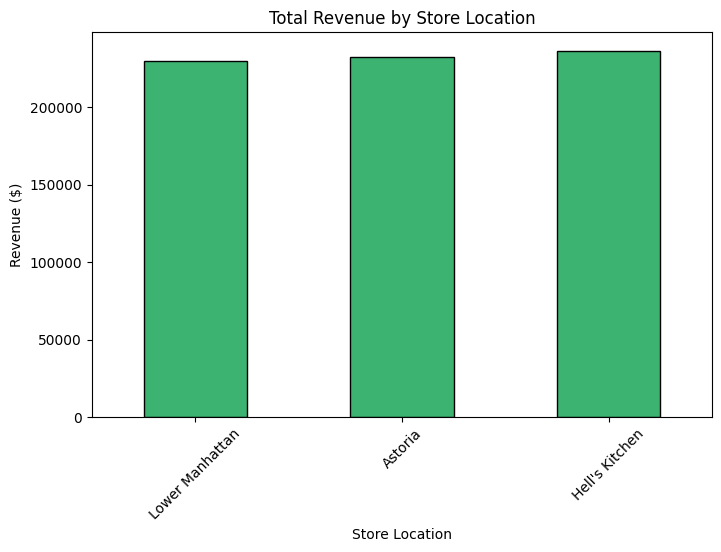

In [11]:
#7. Store-wise Revenue Comparison
df['revenue'] = df['unit_price'] * df['transaction_qty']

plt.figure(figsize=(8,5))
df.groupby('store_location')['revenue'].sum().sort_values().plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title("Total Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

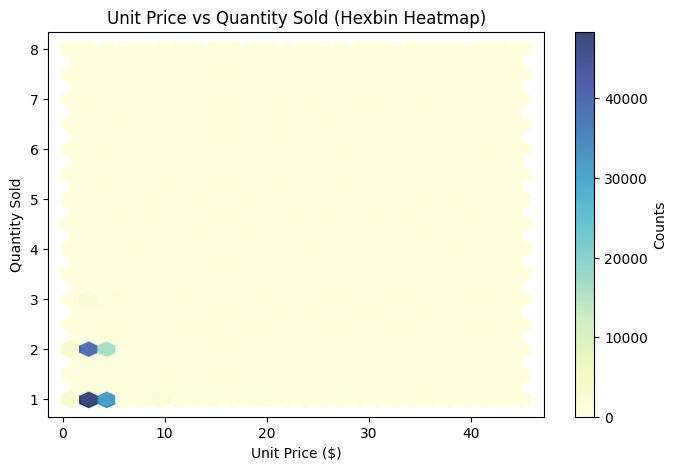

In [19]:
#8. Unit Price vs Quantity Sold (Hexbin Heatmap)
plt.figure(figsize=(8,5))
plt.hexbin(df['unit_price'], df['transaction_qty'], gridsize=25, cmap="YlGnBu", alpha=0.8)
plt.colorbar(label="Counts")
plt.title("Unit Price vs Quantity Sold (Hexbin Heatmap)")
plt.xlabel("Unit Price ($)")
plt.ylabel("Quantity Sold")
plt.show()

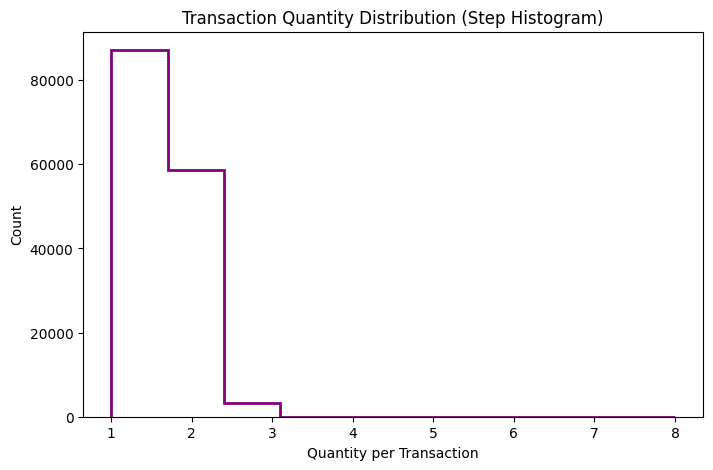

In [15]:
#9. Transaction Quantity Distribution
plt.figure(figsize=(8,5))
plt.hist(df['transaction_qty'], bins=10, color="purple", histtype="step", linewidth=2)
plt.title("Transaction Quantity Distribution (Step Histogram)")
plt.xlabel("Quantity per Transaction")
plt.ylabel("Count")
plt.show()

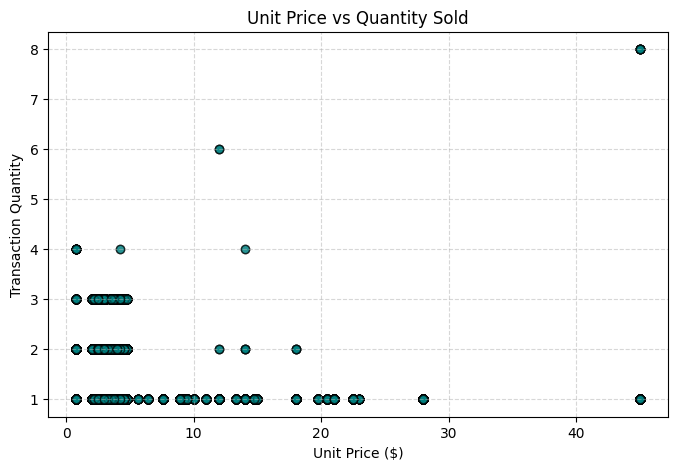

In [16]:
#10. Unit Price vs Quantity Sold
plt.figure(figsize=(8,5))
plt.scatter(df['unit_price'], df['transaction_qty'], color='teal', alpha=0.6, edgecolor='black')
plt.title("Unit Price vs Quantity Sold")
plt.xlabel("Unit Price ($)")
plt.ylabel("Transaction Quantity")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


<Figure size 800x500 with 0 Axes>

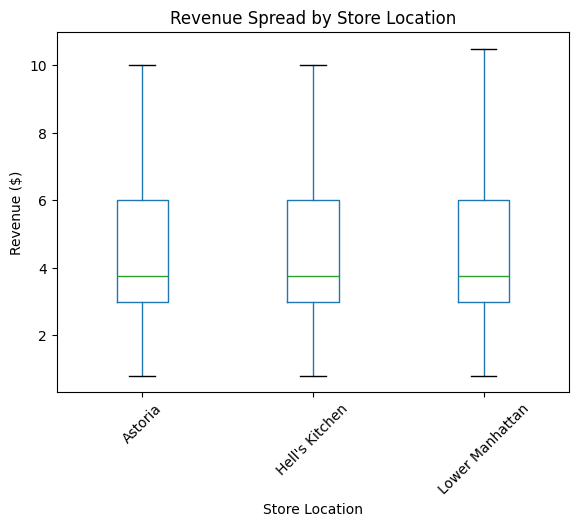

In [17]:
#11. Revenue Spread by Store Location
# Calculate revenue if not already done
df['revenue'] = df['unit_price'] * df['transaction_qty']

plt.figure(figsize=(8,5))
df.boxplot(column="revenue", by="store_location", grid=False, showfliers=False)
plt.title("Revenue Spread by Store Location")
plt.suptitle("")
plt.xlabel("Store Location")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

In [24]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, min, max, sum, countDistinct, year, month, dayofweek, desc


In [34]:
#1. Start Spark session
spark = SparkSession.builder.appName("CoffeeShopSalesAnalysis").getOrCreate()


In [33]:
#2. Read Excel file (converted to CSV first if needed)
df = spark.read.option("header", True).option("inferSchema", True).csv("Coffee_Shop_Sales.csv")

In [32]:
#3. Show sample data
df.show(5)
df.printSchema()


+--------------+----------------+-------------------+---------------+--------+---------------+----------+----------+------------------+--------------------+--------------------+
|transaction_id|transaction_date|   transaction_time|transaction_qty|store_id| store_location|product_id|unit_price|  product_category|        product_type|      product_detail|
+--------------+----------------+-------------------+---------------+--------+---------------+----------+----------+------------------+--------------------+--------------------+
|             1|      01-01-2023|2025-10-06 07:06:11|              2|       5|Lower Manhattan|        32|       3.0|            Coffee|Gourmet brewed co...|         Ethiopia Rg|
|             2|      01-01-2023|2025-10-06 07:08:56|              2|       5|Lower Manhattan|        57|       3.1|               Tea|     Brewed Chai tea|Spicy Eye Opener ...|
|             3|      01-01-2023|2025-10-06 07:14:04|              2|       5|Lower Manhattan|        59|     

In [31]:
#4. Total number of transactions
print("Total number of transactions:", df.count())


Total number of transactions: 149116


In [38]:
#5.min and max of unit_price
from pyspark.sql.functions import min, max
df.select(min("unit_price").alias("Min Price"), max("unit_price").alias("Max Price")).show()


+---------+---------+
|Min Price|Max Price|
+---------+---------+
|      0.8|     45.0|
+---------+---------+



In [39]:
#6. min and max total amounts
from pyspark.sql.functions import col, min, max
df = df.withColumn("total_amount", col("transaction_qty") * col("unit_price"))
df.select(min("total_amount").alias("Min Sale"), max("total_amount").alias("Max Sale")).show()


+--------+--------+
|Min Sale|Max Sale|
+--------+--------+
|     0.8|   360.0|
+--------+--------+



In [52]:

#7. DayOfWeek | Min Total Amount | Max Total Amount 
from pyspark.sql.functions import dayofweek, col, to_date, sum
df_with_date = df.withColumn(
    "transaction_date_parsed", 
    to_date(col("transaction_date"), "dd-MM-yyyy")
)
df_with_dayofweek = df_with_date.withColumn(
    "DayOfWeek", 
    dayofweek(col("transaction_date_parsed"))
)
df_with_dayofweek.groupBy("DayOfWeek") \
    .agg(sum("total_amount").alias("Total Sales")) \
    .orderBy("DayOfWeek") \
    .show()


+---------+------------------+
|DayOfWeek|       Total Sales|
+---------+------------------+
|        1| 98330.30999999992|
|        2|101677.27999999998|
|        3| 99455.94000000008|
|        4|100313.53999999995|
|        5|100767.77999999997|
|        6|101373.00000000006|
|        7| 96894.48000000001|
+---------+------------------+



In [42]:
# 8. Average sales amount per transaction
df = df.withColumn("total_amount", col("transaction_qty") * col("unit_price"))
df.select(avg("total_amount").alias("Average Sale Amount")).show()


+-------------------+
|Average Sale Amount|
+-------------------+
|  4.686367190643667|
+-------------------+



In [44]:
print(df.columns)


['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'total_amount']


In [46]:
#9. Products in a Store and Category with Revenue Greater than the Store’s Average Revenue

from pyspark.sql.functions import col, avg, desc
df = df.withColumn("revenue", col("transaction_qty") * col("unit_price"))
store_name = df.select("store_location").distinct().first()[0]
category_name = df.select("product_category").distinct().first()[0]
print(f"Using store: {store_name}, category: {category_name}")
avg_revenue = (
    df.filter(col("store_location") == store_name)
      .agg(avg("revenue").alias("avg_revenue"))
      .collect()[0]["avg_revenue"]
)
print(f"Average revenue for store '{store_name}':", avg_revenue)
result = (
    df.filter((col("store_location") == store_name) &
              (col("product_category") == category_name) &
              (col("revenue") > avg_revenue))
      .select("transaction_id", "product_id", "product_type", "revenue", "store_location")
      .orderBy(desc("revenue"))
)
result.show(10)
print("Total records found:", result.count())


Using store: Lower Manhattan, category: Coffee
Average revenue for store 'Lower Manhattan': 4.81472625674937
+--------------+----------+----------------+-------+---------------+
|transaction_id|product_id|    product_type|revenue| store_location|
+--------------+----------+----------------+-------+---------------+
|         94586|        41|Barista Espresso|   17.0|Lower Manhattan|
|        129465|        41|Barista Espresso|   17.0|Lower Manhattan|
|         12185|        39|Barista Espresso|  12.75|Lower Manhattan|
|        138695|        39|Barista Espresso|  12.75|Lower Manhattan|
|         27412|        39|Barista Espresso|  12.75|Lower Manhattan|
|        104533|        41|Barista Espresso|  12.75|Lower Manhattan|
|         12350|        39|Barista Espresso|  12.75|Lower Manhattan|
|         49205|        41|Barista Espresso|  12.75|Lower Manhattan|
|          9881|        41|Barista Espresso|  12.75|Lower Manhattan|
|        102114|        39|Barista Espresso|  12.75|Lower Manha

In [47]:
# 10. Increase unit price by 10% for Coffee category products sold in quantity > 3
from pyspark.sql.functions import col, when, round
df_updated = df.withColumn(
    "updated_unit_price",
    when((col("product_category") == "Coffee") & (col("transaction_qty") > 3),
         round(col("unit_price") * 1.10, 2))  # 10% increase
    .otherwise(col("unit_price"))
)
print("Updated unit prices for high-volume Coffee sales:")
df_updated.filter((col("product_category") == "Coffee") & (col("transaction_qty") > 3)) \
          .select("transaction_id", "product_id", "product_category", "transaction_qty", "unit_price", "updated_unit_price") \
          .show()


Updated unit prices for high-volume Coffee sales:
+--------------+----------+----------------+---------------+----------+------------------+
|transaction_id|product_id|product_category|transaction_qty|unit_price|updated_unit_price|
+--------------+----------+----------------+---------------+----------+------------------+
|         94586|        41|          Coffee|              4|      4.25|              4.68|
|        129465|        41|          Coffee|              4|      4.25|              4.68|
+--------------+----------+----------------+---------------+----------+------------------+



# Conclusion
The dataset provides insights into the sales patterns of a mid-sized coffee shop chain across multiple stores and products. Day-wise analysis shows how sales fluctuate throughout the week, helping identify peak business days. The minimum, maximum, and total sales per day reveal the variability in daily revenue, highlighting high-performing days and potential opportunities to boost lower-performing periods. Products and store locations show consistent contribution to overall revenue, suggesting balanced demand across offerings. This dataset is well-suited for sales trend analysis, inventory planning, and promotional strategy development to optimize revenue and operational efficiency